# Import packages

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.integrate as integrate
from iminuit import Minuit
from sklearn.neighbors import KernelDensity
import pandas as pd
plt.rcParams.update({'axes.labelsize': 'large'})

# Open the data

In [2]:
all_data = np.load("project3_data_version1.npz.sec") 
data = all_data['data']
signal_mc = all_data['signal_mc']
bb_mc = all_data['bb_mc']
qq_mc = all_data['qq_mc']

#print data shapes
print("shapes",data.shape,signal_mc.shape,bb_mc.shape,qq_mc.shape)

shapes (2672, 3) (10000, 3) (10000, 3) (10000, 3)


# Task 1)
*Create histograms for all three categories: signal, bb, qq and demonstrate that these quantities are useful.*

In [3]:
def plot_binned_data_with_errorbar(x, nbins, color, label, density=False, range=None):
    histo = np.histogram(x,bins=nbins,range=range)
    yi = histo[0]
    xx = histo[1]
    xi = (xx[:-1]+xx[1:])/2 
    y_errors = np.sqrt(yi)
        
    if density == False:
        plt.errorbar(xi, yi, y_errors, fmt='.', color=color, label=label)
        hist_range = [xx[0], xx[-1]]
        return xi,yi,hist_range
      
    #for task 6, 7, 8 add some density condition
    if density == True:
        yi = histo[0] / (len(x) * (xx[1]-xx[0]))
        y_errors = y_errors / (len(x) * (xx[1]-xx[0]))
        plt.gca().errorbar(xi, yi, y_errors, fmt='.', color=color, label=label)
        hist_range = [xx[0], xx[-1]]
        return xi,yi,hist_range

def make_hist(observable : int, Nbins = 100):
    #set labels
    observable_label=[r'$\Delta E \,\, (\mathrm{Gev})$', r'$M_{bc}\,\, (\mathrm{Gev}/\mathrm{c}^2)$', r'$qq_{suppression}$']
    label=observable_label[observable]
    
    #create plot
    plot_binned_data_with_errorbar(signal_mc[:,observable], nbins=Nbins, color='blue', label='signal')
    plot_binned_data_with_errorbar(bb_mc[:,observable], nbins=Nbins, color='red', label='bb')
    plot_binned_data_with_errorbar(qq_mc[:,observable], nbins=Nbins, color='green', label='qq')
    
    #plot specifications
    plt.grid(alpha=0.3)
    plt.legend()
    plt.ylabel('counts')
    plt.xlabel(label)
    plt.show()

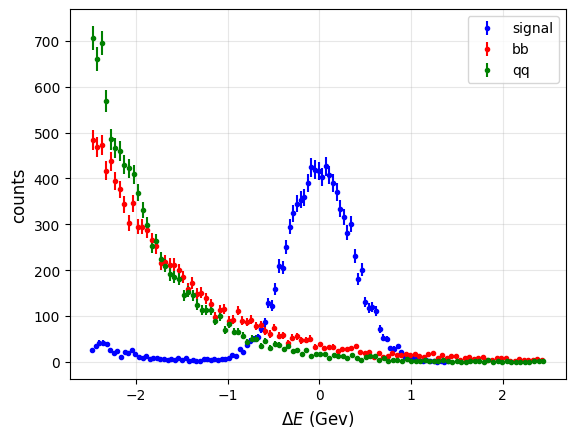

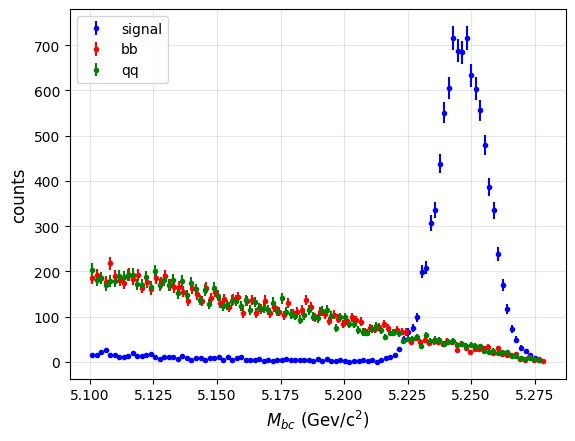

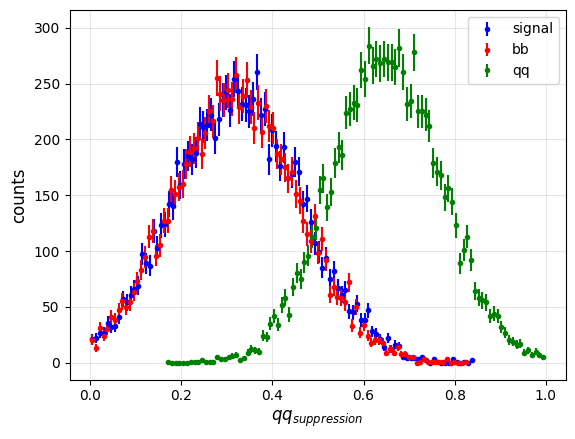

In [4]:
make_hist(0)
make_hist(1)
make_hist(2)


We see that the "signal_mc" data has some Gaussian distributed values (around different values each) and thus correspond to what we would expect from our simulated data. The other two datasets clearly correspond to some kind of background and has noisy character.

# Task 2)
*Demonstrate that for the signal sample there is a clear correlation between two variables.*

### Covariance and correlation
Consider the random variables $A,B$. The correlation function $\mathrm{Corr}(AB)$ tells us how strongly these two variables are correlated:
\begin{align*}
& \mathrm{Cov}(AB) = \braket{\left( A - \braket{A} \right) \left( B - \braket{B} \right)} = \braket{AB} - \braket{A}\braket{B} && \textcolor{gray}{\text{covariance}}\\
&\mathrm{Corr}(AB) = \frac{\braket{\left( A - \braket{A} \right) \left( B - \braket{B} \right)}}{\sigma_A \sigma_B} = \frac{\braket{AB} - \braket{A}\braket{B}}{\sigma_A \sigma_B} && \textcolor{gray}{\text{correlation}}
\end{align*}
where $\sigma_A, \sigma_B$ are the standard deviations. For $\mathrm{Corr}(AB) = 0$ the two variables are called independent and it holds $\braket{A + B} = \braket{A} + \braket{B}$. The covariance is a dimensionful measure of correlation.

The correlation (or same for covariance) matrix of a set of variables $x_1,\dots, x_N$ is a $N\times N$ matrix defined by its matrix elements 
$$
C_{ij} = \mathrm{Corr}(x_i,x_j)
$$

In order to check for correlation here, we will use the "numpy.corrcoef" function, which gives the normalized covariance matrix via the components:
$$
R_{ij} = \frac{C_{ij}}{\sqrt{C_{ii} C_{jj}}}
$$.

In [5]:
signal_deltaE = signal_mc[:,0]
signal_Mbc = signal_mc[:,1]
signal_qq = signal_mc[:,2]

#since the correlation matrix is symmetric we only examine the upper right matrixelement
print('Corr(DeltaE, Mbc) = ' + str(np.corrcoef(signal_deltaE, signal_Mbc)[1:,0]) )
print('Corr(DeltaE, qq_suppression) = ' + str(np.corrcoef(signal_deltaE, signal_qq)[1:,0])  )
print('Corr(qq_suppression, Mbc) = ' + str(np.corrcoef(signal_qq, signal_Mbc)[1:,0])  )

Corr(DeltaE, Mbc) = [0.67968181]
Corr(DeltaE, qq_suppression) = [0.001552]
Corr(qq_suppression, Mbc) = [-0.00145952]


We see that for the "signal_mc"-Dataset there is a clear dependence between the variables "deltaE" and "Mbc".

# Task 3)
*Explain why this is relevant if you want to perform an unbinned Maximum likelihood fit*

If the data is correlated, it means that the events are not randomly distributed, and therefore the PDF is not accurately represented by an unbinned likelihood fit. Correlated data can lead to overfitting or underfitting of the model, resulting in poor predictive power.

Furthermore, correlated data violates the assumption of independence between events, which is a key assumption in the maximum likelihood method. Without this assumption, the likelihood function may not correctly represent the true underlying probability distribution, leading to inaccurate parameter estimates.


# Task 4)
*Select a subsample of the signal that has nearly uncorrelated observables.*

In the following we will plot the different observables against each other in order to find some restrictions for these to be nearly uncorrelated.


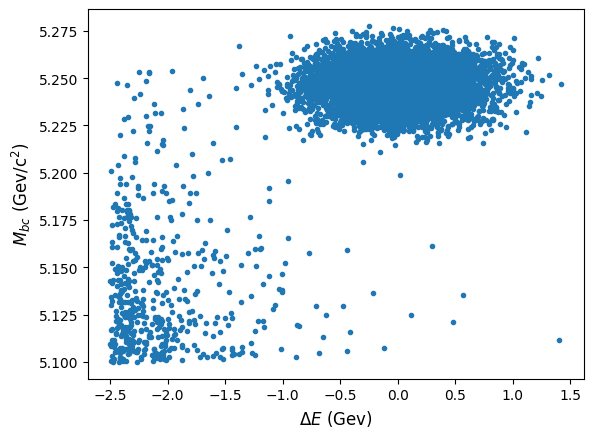

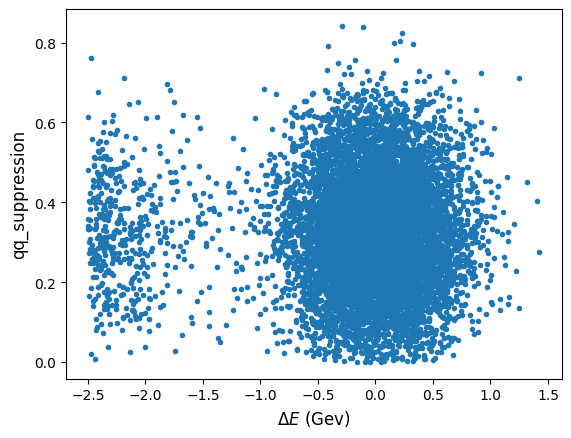

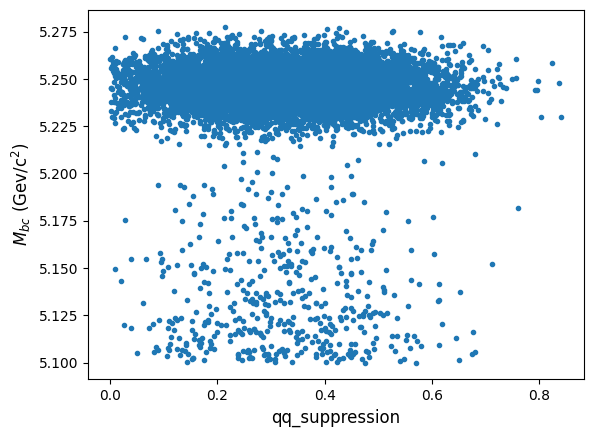

In [6]:
plt.plot(signal_deltaE, signal_Mbc,'.' )
plt.xlabel(r'$\Delta E \,\, (\mathrm{Gev})$')
plt.ylabel(r'$M_{bc}\,\, (\mathrm{Gev}/\mathrm{c}^2)$')
plt.show()

plt.plot(signal_deltaE, signal_qq,'.' )
plt.xlabel(r'$\Delta E \,\, (\mathrm{Gev})$')
plt.ylabel('qq_suppression')
plt.show()

plt.plot(signal_qq, signal_Mbc,'.' )
plt.xlabel('qq_suppression')
plt.ylabel(r'$M_{bc}\,\, (\mathrm{Gev}/\mathrm{c}^2)$')
plt.show()


We can see that there are mainly two areas where the data points concetrate. If we now isolate the more denser clouds, we can thus reduce the correlation while keeping the main part of our data. We now set a limitation to one of the observables and check the correaltion:

Corr(DeltaE, Mbc) = [0.05433979]
The length of the subset is 9538 compared to the original length of 10000


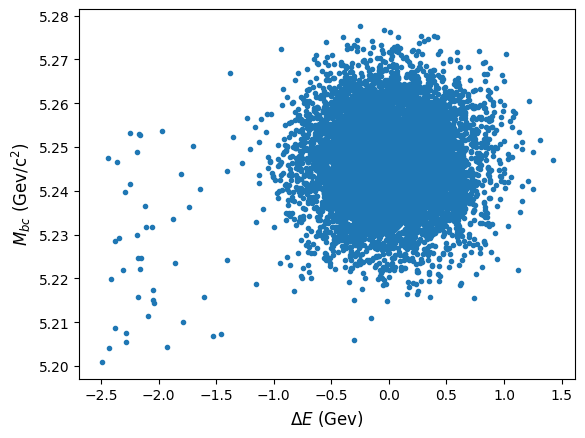

In [7]:
#choose a limitation for one observable by hand
Mbc_lim = 5.2

#select subset
def select_subset(array_of_observables, Mbc_lim : np.ndarray):
    #ensure we are working with numpy array
    array = np.array(array_of_observables)
    #create arrays with bools (determined by the limits) for the first two observables
    bool_array = array[:,1] > Mbc_lim
    #return the selected array elements
    return array_of_observables[bool_array]

#examine the plot once more with selection
subset_signal_mc = select_subset(signal_mc, Mbc_lim)
plt.plot(subset_signal_mc[:,0], subset_signal_mc[:,1],'.' )
plt.xlabel(r'$\Delta E \,\, (\mathrm{Gev})$')
plt.ylabel(r'$M_{bc}\,\, (\mathrm{Gev}/\mathrm{c}^2)$')

#calculate the correlation again
print('Corr(DeltaE, Mbc) = ' + str(np.corrcoef(subset_signal_mc[:,0], subset_signal_mc[:,1])[1:,0]) )

#examine the length of the subset
print('The length of the subset is ' + str(len(subset_signal_mc[:,0])) + ' compared to the original length of 10000' )


As we can see the correlation is now of the same order as the one of the other observables. Also we notice that we only excluded a few data points from our original dataset to obtain this correlation. 

# Task 5)
*Apply this selection to all sample (data, signal,bb,qq) and continue your analysis.*

In the last part we already defined a function that selects the desired subsets for given limit in the observables. We now keep this limit and apply the selection to all our data:


In [8]:
#recall the shapes of our all our datasets
print("shapes before",data.shape,signal_mc.shape,bb_mc.shape,qq_mc.shape)

#redefine our arrays with the selection rule
data = select_subset(data, Mbc_lim)
signal_mc = select_subset(signal_mc, Mbc_lim)
bb_mc = select_subset(bb_mc, Mbc_lim)
qq_mc = select_subset(qq_mc, Mbc_lim)

#check the shapes after selection
print("shapes after",data.shape,signal_mc.shape,bb_mc.shape,qq_mc.shape)

signal_deltaE = signal_mc[:,0]
signal_Mbc = signal_mc[:,1]
signal_qq = signal_mc[:,2]

#since the correlation matrix is symmetric we only examine the upper right matrixelement
print('Corr(DeltaE, Mbc) = ' + str(np.corrcoef(signal_deltaE, signal_Mbc)[1:,0]) )
print('Corr(DeltaE, qq_suppression) = ' + str(np.corrcoef(signal_deltaE, signal_qq)[1:,0])  )
print('Corr(qq_suppression, Mbc) = ' + str(np.corrcoef(signal_qq, signal_Mbc)[1:,0])  )


shapes before (2672, 3) (10000, 3) (10000, 3) (10000, 3)
shapes after (583, 3) (9538, 3) (1940, 3) (1884, 3)
Corr(DeltaE, Mbc) = [0.05433979]
Corr(DeltaE, qq_suppression) = [-0.00543982]
Corr(qq_suppression, Mbc) = [-0.01084352]


As we see in the shapes of our datasets the selection has a massive impact on the "data", "bb_mc" and "qq_mc" arrays.

# Task 6)
*Model the probability density to observe an event with quantities deltaE, Mbc, qq_suppression*

Since the observables are now all uncorrelated we can model the probability density seperately for each observable.


In [9]:
#example for creating a one-dimensional probability density from data using kernel-density estimation
class prob_density_1d:
    def __init__(self,mc,epsilon):
        assert(mc.shape == (len(mc),) or mc.shape==(len(mc),1))
        self.kde = KernelDensity(kernel='gaussian', bandwidth=epsilon).fit(mc.reshape((len(mc),1)))
    def __call__(self,x):
        return np.exp(self.kde.score_samples(x.reshape((len(x),1))))


def plot_pdf(x, hist_label, xlabel, bandwidth, nbins=50):
    #create pdf
    pdf = prob_density_1d(x, bandwidth)
    
    #make plot
    plt.figure()
    _,__,hist_range = plot_binned_data_with_errorbar(x, nbins=nbins, color='orange', label=hist_label, density=True)
    xplot=np.linspace(hist_range[0], hist_range[1],len(x))
    plt.plot(xplot, pdf(xplot), color='black', label='pdf')
    
    #plot specidications
    plt.grid(alpha=0.3)
    plt.legend()
    plt.xlabel(xlabel)
    plt.ylabel('counts')
    #plt.show()

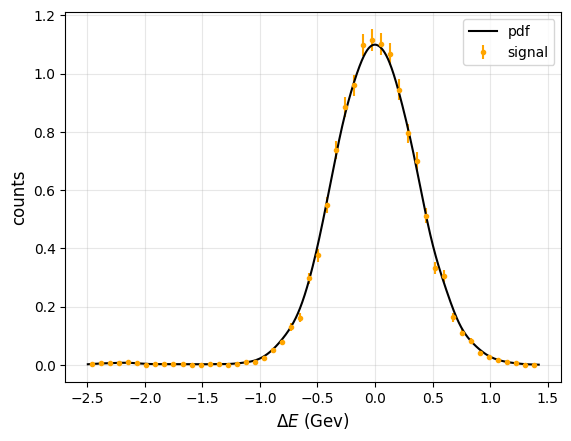

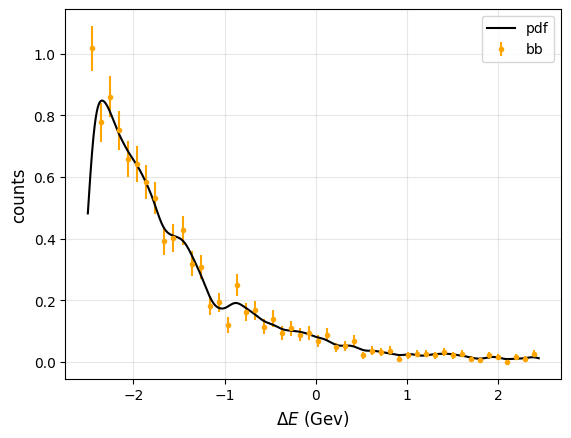

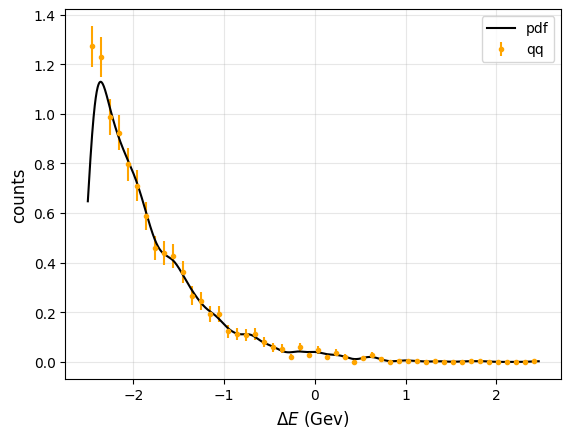

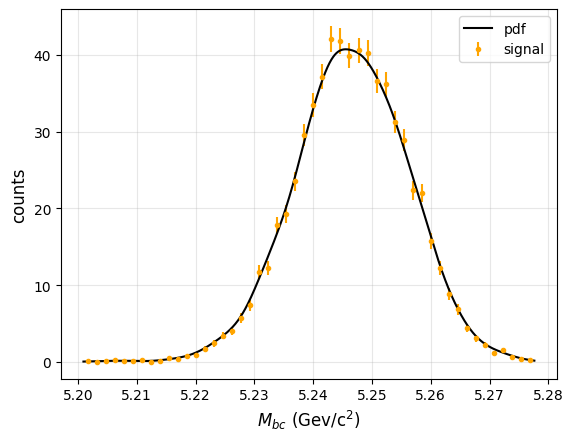

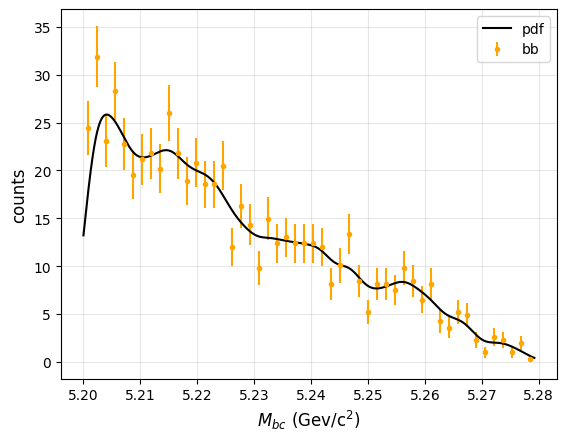

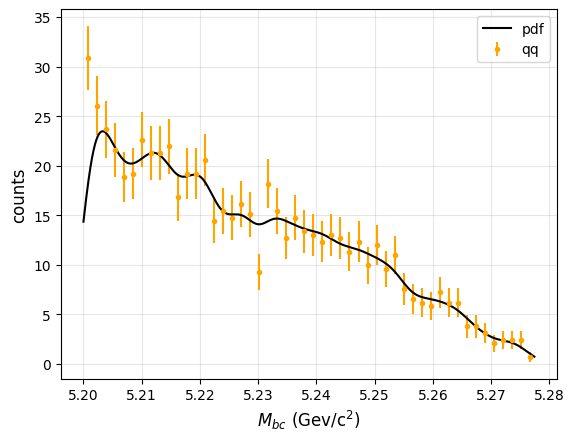

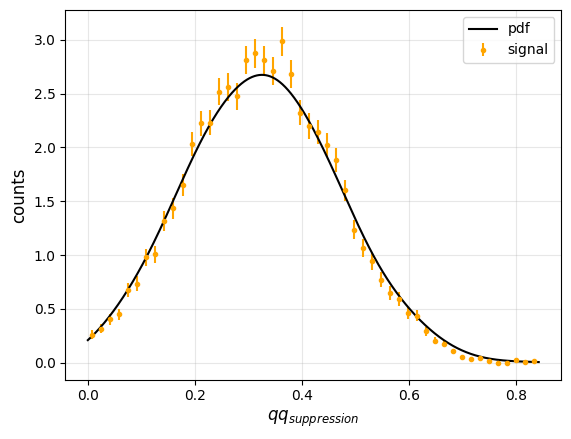

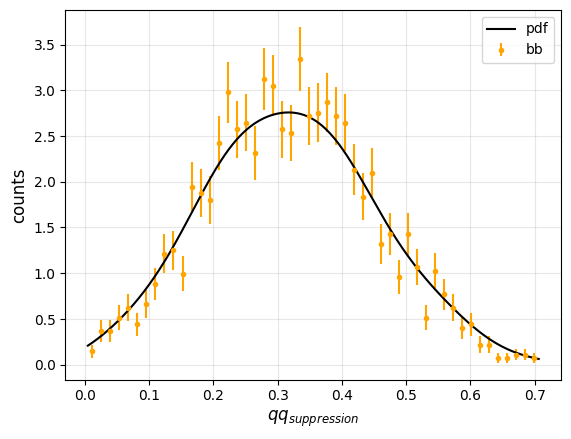

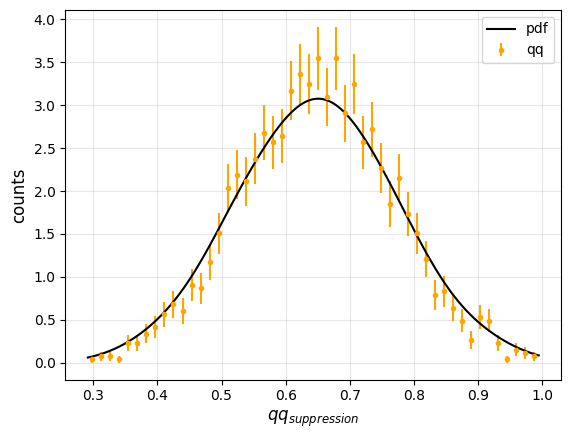

In [10]:
plot_pdf(signal_mc[:,0], 'signal', r'$\Delta E \,\, (\mathrm{Gev})$', 0.08)
plot_pdf(bb_mc[:,0], 'bb', r'$\Delta E \,\, (\mathrm{Gev})$', 0.08)
plot_pdf(qq_mc[:,0], 'qq', r'$\Delta E \,\, (\mathrm{Gev})$', 0.08)

plot_pdf(signal_mc[:,1], 'signal', r'$M_{bc}\,\, (\mathrm{Gev}/\mathrm{c}^2)$', 0.002)
plot_pdf(bb_mc[:,1], 'bb', r'$M_{bc}\,\, (\mathrm{Gev}/\mathrm{c}^2)$', 0.002)
plot_pdf(qq_mc[:,1], 'qq', r'$M_{bc}\,\, (\mathrm{Gev}/\mathrm{c}^2)$', 0.002)

plot_pdf(signal_mc[:,2], 'signal', r'$qq_{suppression}$', 0.05)
plot_pdf(bb_mc[:,2], 'bb', r'$qq_{suppression}$', 0.05)
plot_pdf(qq_mc[:,2], 'qq', r'$qq_{suppression}$', 0.05)

# Task 7) 
- *create a sample of MC events with 50 signal, 1000 BB, 1000 qq by randomly drawing from the MC samples.*
- *Apply your fit to this sample and verify that your method works. Repeat this procedure a few times and create a pull distribution.*
- *Do this also for MC samples with 100 signal, 1000 BB, 10000 qq.*

In [11]:
#create the samples
def draw_sample_from_mc(array_of_observables, sample_length):
    rand_var = []
    for a in range(0, sample_length):
        index = np.random.choice(len(array_of_observables))   #draws an index of the array
        event = [ array_of_observables[:,0][index], array_of_observables[:,1][index], array_of_observables[:,2][index] ]
        rand_var.append(event)
    
    #format array
    rand_var = np.array(rand_var)
    return rand_var


#the pdf for the sampled data has to be a combination of the weighted pdfs
def make_pdf(x, obs, bandwidth, signal_len, bb_len, qq_len):
    pdf_signal = prob_density_1d(signal_mc[:,obs], bandwidth)
    pdf_bb = prob_density_1d(bb_mc[:,obs], bandwidth)
    pdf_qq = prob_density_1d(qq_mc[:,obs], bandwidth)
    
    full_pdf = (signal_len * pdf_signal(x) + bb_len * pdf_bb(x) + qq_len * pdf_qq(x)) / (signal_len + bb_len + qq_len)
    return full_pdf


#plot the full pdf 
def plot_full_pdf(x, obs, hist_label, xlabel, bandwidth, signal_len, bb_len, qq_len, nbins=50 ):
    #create pdf
    
    #make plot
    plt.figure()
    _,__,hist_range = plot_binned_data_with_errorbar(x, nbins=nbins, color='orange', label=hist_label, density=True)
    xplot=np.linspace(hist_range[0], hist_range[1],len(x))
    plt.plot(xplot, make_pdf(xplot, obs, bandwidth, signal_len, bb_len, qq_len), color='black', label='pdf')
    
    #plot specidications
    plt.grid(alpha=0.3)
    plt.legend()
    plt.xlabel(xlabel)
    plt.ylabel('counts')
    plt.show()

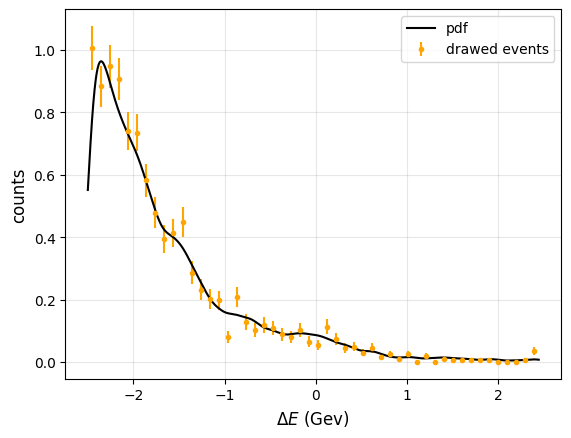

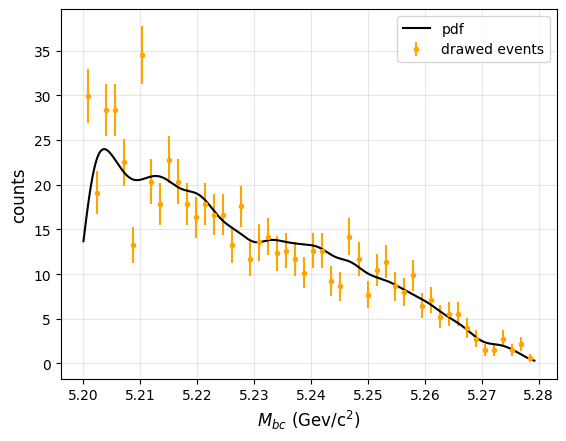

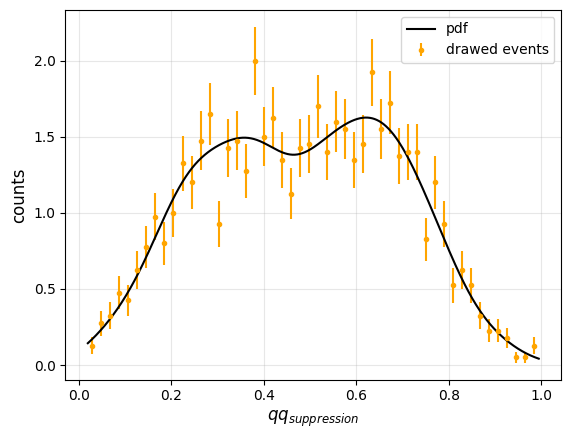

In [12]:
#generate samples
a1 = draw_sample_from_mc(signal_mc, 50)
a2 = draw_sample_from_mc(bb_mc, 1000)
a3 = draw_sample_from_mc(qq_mc, 1000)

#put all arrays together
a4 = np.concatenate((a1,a2,a3))

#make plot
plot_full_pdf(a4[:,0], 0, 'drawed events', r'$\Delta E \,\, (\mathrm{Gev})$', 0.08, 50, 1000, 1000)

plot_full_pdf(a4[:,1], 1, 'drawed events', r'$M_{bc}\,\, (\mathrm{Gev}/\mathrm{c}^2)$', 0.002, 50, 1000, 1000)

plot_full_pdf(a4[:,2], 2, 'drawed events', r'$qq_{suppression}$', 0.05, 50, 1000, 1000)

In [13]:
#create a pull distribution with pull = (mu_meas - mu_true) / sigma_meas
def create_pull(mu_true, pull_number, obs, signal_len, bb_len, qq_len):
    pull = []
    
    #create sample a few times
    for i in range(0, pull_number):
        #generate samples
        a1 = draw_sample_from_mc(signal_mc, signal_len)
        a2 = draw_sample_from_mc(bb_mc, bb_len)
        a3 = draw_sample_from_mc(qq_mc, qq_len)

        #put all arrays together and select observable
        a4 = np.concatenate((a1,a2,a3))[:,obs]
        
        #calculate pull
        mu_meas = np.mean(a4)
        sigma = np.std(a4)
        pull.append( (mu_meas - mu_true) / sigma )
    
    return np.array(pull)


#plot the pull distribution
def plot_pull(obs, bandwidth, pull_number, label, color, signal_len, bb_len, qq_len, nbins=50):
    
    #generate pdf input
    x_array = np.linspace(np.min(signal_mc[:,obs]), np.max(signal_mc[:,obs]), 10000)
    #generate pdf
    prob = make_pdf(x_array, obs, bandwidth, signal_len, bb_len, qq_len)
    
    #calculate the true mean via mu = \int dx x*rho(x) , with normalisation
    mu_true = (np.sum(x_array * prob) / np.sum(prob))
    
    #generate pull data
    pull = create_pull(mu_true, pull_number, obs, signal_len, bb_len, qq_len)

    #plot hist
    plot_binned_data_with_errorbar(pull, nbins, color, label)
    #plot specifications
    plt.grid(alpha=0.3)
    plt.legend()
    plt.ylabel('counts')
    plt.xlabel('pull')

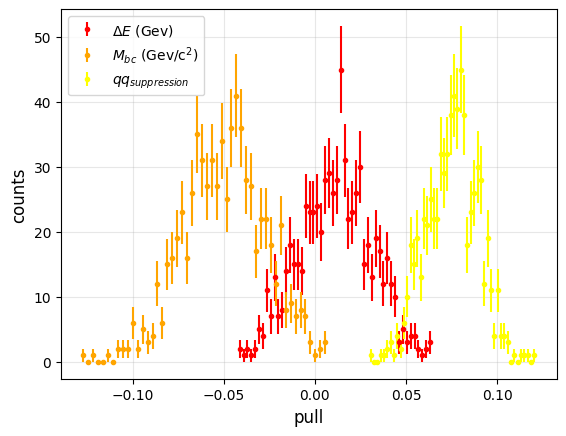

In [14]:
plot_pull(0, 0.05, 700, r'$\Delta E \,\, (\mathrm{Gev})$', 'red', 50, 1000, 1000)
plot_pull(1, 0.002, 700, r'$M_{bc}\,\, (\mathrm{Gev}/\mathrm{c}^2)$', 'orange', 50, 1000, 1000)
plot_pull(2, 0.08, 700, r'$qq_{suppression}$', 'yellow', 50, 1000, 1000)
plt.show()

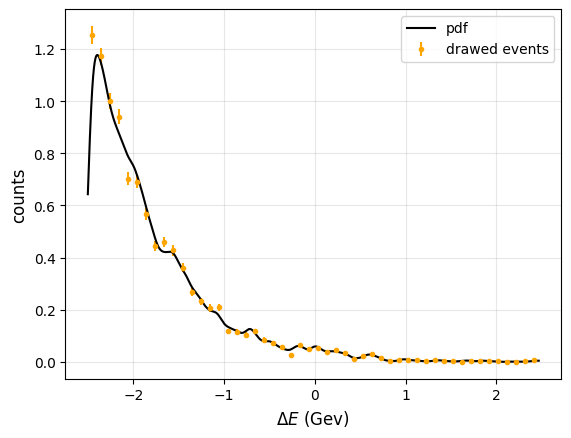

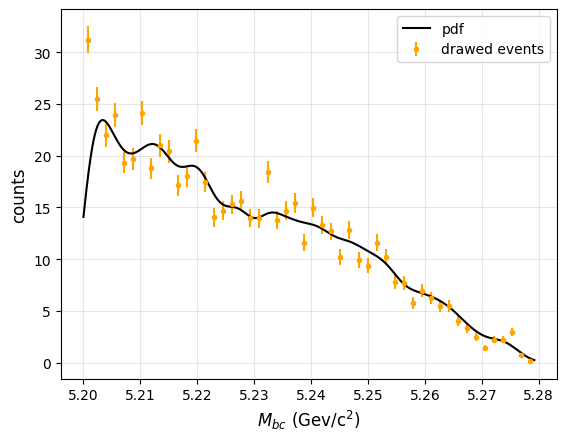

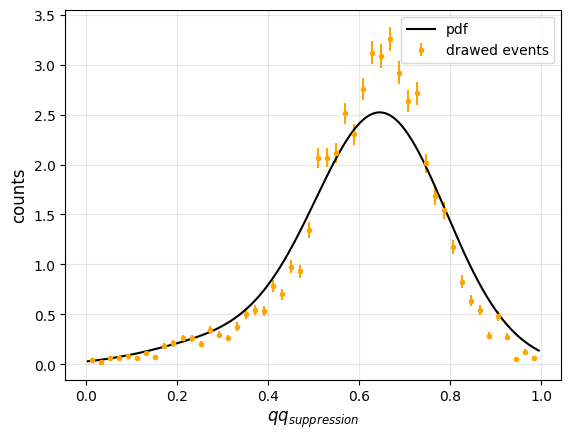

In [15]:
#repeat procedure for different sample length

#generate samples
a1 = draw_sample_from_mc(signal_mc, 100)
a2 = draw_sample_from_mc(bb_mc, 1000)
a3 = draw_sample_from_mc(qq_mc, 10000)

#put all arrays together
a4 = np.concatenate((a1,a2,a3))

#make plot
plot_full_pdf(a4[:,0], 0, 'drawed events', r'$\Delta E \,\, (\mathrm{Gev})$', 0.05, 100, 1000, 10000)
plot_full_pdf(a4[:,1], 1, 'drawed events', r'$M_{bc}\,\, (\mathrm{Gev}/\mathrm{c}^2)$', 0.002, 100, 1000, 10000)
plot_full_pdf(a4[:,2], 2, 'drawed events', r'$qq_{suppression}$', 0.08, 100, 1000, 10000)

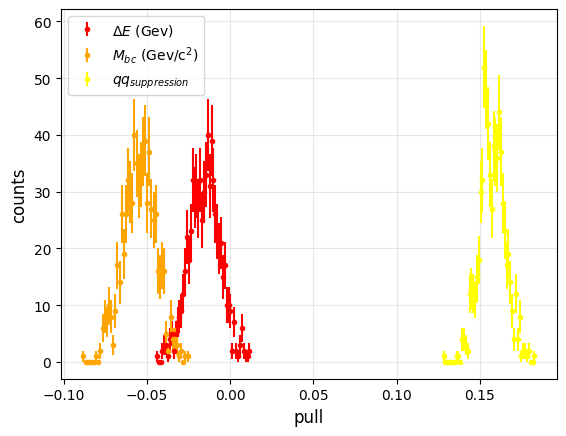

In [16]:
#plot pull distribution
plot_pull(0, 0.05, 700, r'$\Delta E \,\, (\mathrm{Gev})$', 'red', 100, 1000, 10000)
plot_pull(1, 0.002, 700, r'$M_{bc}\,\, (\mathrm{Gev}/\mathrm{c}^2)$', 'orange', 100, 1000, 10000)
plot_pull(2, 0.08, 700, r'$qq_{suppression}$', 'yellow', 100, 1000, 10000)
plt.show()

# Task 8) 
*Apply an unbinned ML fit (extended or regular) to the data.*

Here we will perform a regular ML fit.

In [17]:
#set global variable for bandwidth
bandwidth = [0.05, 0.002, 0.08]


#apply unbinned ML fit to the events in the data array
def neg_log_L(f1, f2):
    log_L = 0
    for OBSERVABLE in range(0,3):
        p = full_pdf(data[:,OBSERVABLE], OBSERVABLE, f1,f2, bandwidth[OBSERVABLE])
        for i in range(0,len(data[:,OBSERVABLE])):
            log_L += np.log(p[i])
    return -log_L

#define the pdf
def full_pdf(x, obs, f1, f2, bandwidth):
    pdf1 = prob_density_1d(signal_mc[:,obs], bandwidth)
    pdf2 = prob_density_1d(bb_mc[:,obs], bandwidth)
    pdf3 = prob_density_1d(qq_mc[:,obs], bandwidth)
    #restraint
    f3 = len(data[:,0]) - f1 - f2
    return ( (f1 * pdf1(x)) + (f2 * pdf2(x)) + (f3 * pdf3(x)) ) / (f1 + f2 + f3)

#minimize the neg-log-L
def minimize():
    # Set initial parameter values and bounds
    init_values = {'f1': 130, 'f2': 250}
    lower_bounds = {'f1': 1, 'f2': 1}
    upper_bounds = {'f1': 250, 'f2': 350}

    # Create Minuit object and set parameters
    minuit = Minuit(neg_log_L, **init_values)
    minuit.limits = [(lower_bounds[param], upper_bounds[param]) for param in init_values]
    minuit.errordef = Minuit.LIKELIHOOD 

    minuit.migrad()
    minuit.hesse()

    #call the parameter values and errors
    f = minuit.values
    f_err = minuit.errors

    minuit
    
    return f, f_err

In [18]:
#make plot
def plot_ML(f, obs):
    #set parameter values
    f1=f[0]
    f2=f[1]

    #set x values for ML fit and labels
    xvals = np.linspace(np.min(data[:,obs]), np.max(data[:,obs]), 10000)
    label = [r'$\Delta E \,\, (\mathrm{Gev})$', r'$M_{bc}\,\, (\mathrm{Gev}/\mathrm{c}^2)$', r'$qq_{suppression}$']

    #plot data and ML fit
    plot_binned_data_with_errorbar(data[:,obs], 50, 'orange', 'data', density=True)
    plt.plot(xvals, full_pdf(xvals, obs, f1, f2, bandwidth[obs]), label='ML fit')

    #plot specifications
    plt.legend()
    plt.xlabel(label[obs])
    plt.ylabel('counts')
    plt.grid(alpha=0.3)
    plt.show()

In [19]:
#get the fit parameters
#----------------------
#call minuit
f, f_err = minimize()

#check if the sum of f1,f2,f3 is equal to total number of events
f1, f1_err = f[0], f_err[0]
f2, f2_err = f[1], f_err[1]
f3, f3_err = len(data[:,0]) - f[0] - f[1], np.sqrt( (f1_err)**2 + (f2_err)**2 ) #gaussian error propagation

#print parameters
print('N_tot = ' + str(len(data[:,0])))
print('f1 = ' + str(f1) + ' +/- ' + str(f1_err))
print('f2 = ' + str(f2) + ' +/- ' + str(f2_err))
print('f3 = ' + str(f3) + ' +/- ' + str(f3_err))

N_tot = 583
f1 = 137.85256490317215 +/- 10.66328239499284
f2 = 251.9019390810872 +/- 18.15519988651566
f3 = 193.24549601574066 +/- 21.05509141169191


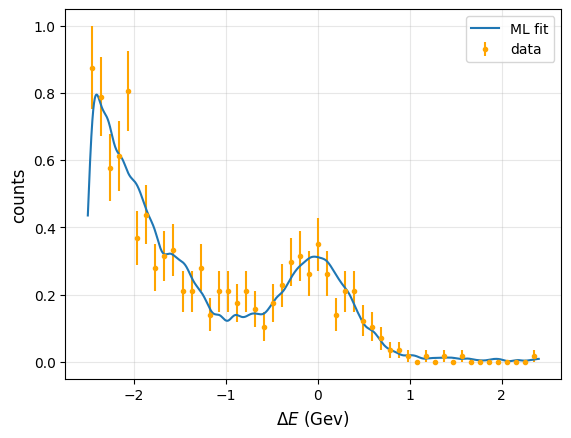

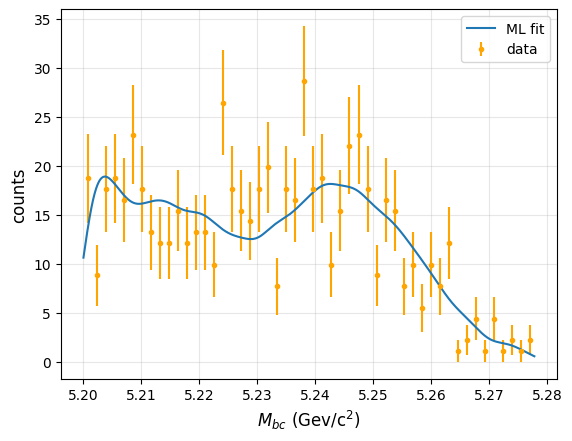

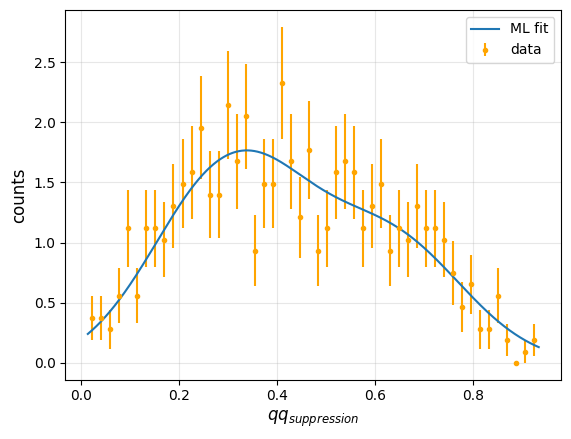

In [20]:
#make plot
#---------
plot_ML(f,0)

plot_ML(f,1)

plot_ML(f,2)

# Task 9)
*Determine the cross section with errors. Do not forget to apply a correction to take into account your preselection.*

In [21]:
#calculate the fraction of signal events with error
signal_frac = f1 / (len(data[:,0]))
signal_frac_err = f1_err / (len(data[:,0]))
print('signal fraction: ' + str(signal_frac) + ' +/- ' + str(signal_frac_err))

#we know that 100 signal events correspond to a branching fraction of 1.5*10^-4
factor = (1.5 * 10**(-4)) / 100.

#calculate the full branching fraction
BF = f1 * factor
BF_err = f1_err * factor
print('branching ratio: (' + str(BF*10**4) + ' +/- ' + str(BF_err*10**4) + ') *10^-4')

#estimate error due to preselection
length_before_selection = 10000
length_after_selection = len(signal_mc[:,0])
#percentage of events that pass selection
k = length_after_selection/length_before_selection
print('pourcentage that passes selection: k = ' + str(k))
#estimate error
preselec_err = BF * (1-k)
print('Preselection error: ' + str(preselec_err*10**4)  + ' *10^-4')

signal fraction: 0.23645379914780815 +/- 0.018290364313881372
branching ratio: (2.067788473547582 +/- 0.1599492359248926) *10^-4
pourcentage that passes selection: k = 0.9538
Preselection error: 0.09553182747789835 *10^-4
